In [132]:
from pyspark.sql import SparkSession
from pyspark.sql import Window
from pyspark.sql.functions import col, lag, to_date
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from matplotlib.gridspec import GridSpec

In [133]:
# Initialize Spark Session
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Russian Losses Equipment Analysis") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

# Load data with error handling
try:
    df = spark.read.option("header", True) \
        .option("inferSchema", True) \
        .csv("russia_losses_equipment.csv")
except Exception as e:
    print(f"Error loading data: {e}")

print(f"This is PySpark Version: {spark.version}")

This is PySpark Version: 3.5.1


In [134]:
    # Display schema to understand the data
df.printSchema()

root
 |-- date: date (nullable = true)
 |-- day: integer (nullable = true)
 |-- aircraft: integer (nullable = true)
 |-- helicopter: integer (nullable = true)
 |-- tank: integer (nullable = true)
 |-- APC: integer (nullable = true)
 |-- field artillery: integer (nullable = true)
 |-- MRL: integer (nullable = true)
 |-- military auto: double (nullable = true)
 |-- fuel tank: double (nullable = true)
 |-- drone: integer (nullable = true)
 |-- naval ship: integer (nullable = true)
 |-- anti-aircraft warfare: integer (nullable = true)
 |-- special equipment: double (nullable = true)
 |-- mobile SRBM system: double (nullable = true)
 |-- greatest losses direction: string (nullable = true)
 |-- vehicles and fuel tanks: double (nullable = true)
 |-- cruise missiles: double (nullable = true)
 |-- submarines: double (nullable = true)



In [135]:
try:
    # Show a sample of the data
    df.show(5)
except Exception as e:
    print(f"Error loading data: {e}")

+----------+----+--------+----------+-----+-----+---------------+----+-------------+---------+-----+----------+---------------------+-----------------+------------------+-------------------------+-----------------------+---------------+----------+
|      date| day|aircraft|helicopter| tank|  APC|field artillery| MRL|military auto|fuel tank|drone|naval ship|anti-aircraft warfare|special equipment|mobile SRBM system|greatest losses direction|vehicles and fuel tanks|cruise missiles|submarines|
+----------+----+--------+----------+-----+-----+---------------+----+-------------+---------+-----+----------+---------------------+-----------------+------------------+-------------------------+-----------------------+---------------+----------+
|2025-02-23|1096|     370|       331|10168|21151|          23582|1296|         NULL|     NULL|26428|        28|                 1081|           3757.0|              NULL|                     NULL|                38334.0|         3064.0|       1.0|
|2025-02

In [136]:
    # Ensure date column is properly formatted
df = df.withColumn("date", to_date(col("date"), "yyyy-MM-dd"))

In [137]:
    # Show the transformed data
df.show(5)

+----------+----+--------+----------+-----+-----+---------------+----+-------------+---------+-----+----------+---------------------+-----------------+------------------+-------------------------+-----------------------+---------------+----------+
|      date| day|aircraft|helicopter| tank|  APC|field artillery| MRL|military auto|fuel tank|drone|naval ship|anti-aircraft warfare|special equipment|mobile SRBM system|greatest losses direction|vehicles and fuel tanks|cruise missiles|submarines|
+----------+----+--------+----------+-----+-----+---------------+----+-------------+---------+-----+----------+---------------------+-----------------+------------------+-------------------------+-----------------------+---------------+----------+
|2025-02-23|1096|     370|       331|10168|21151|          23582|1296|         NULL|     NULL|26428|        28|                 1081|           3757.0|              NULL|                     NULL|                38334.0|         3064.0|       1.0|
|2025-02

In [138]:
# Fill null values with zeros only in numeric columns
# Get all columns except date and text columns
numeric_columns = [c for c in df.columns if c not in ["date", "greatest losses direction"]]
for column in numeric_columns:
    df = df.withColumn(column, col(column).cast("double"))
    df = df.fillna(0, subset=[column])

In [139]:
# Calculate columns for daily differences
columns_to_calculate = [c for c in df.columns if c not in ["date", "day", "greatest losses direction"]]

In [140]:
# Create window spec for calculating daily differences
# Adding a hint to improve performance
windowSpec = Window.orderBy("date")

# Calculate daily differences for each equipment type
daily_loss_exprs = [(col(c) - lag(col(c), 1).over(windowSpec)).alias(f"daily_{c}") 
                   for c in columns_to_calculate]

# Select date and daily loss columns
daily_loss_df = df.select("date", *daily_loss_exprs)

In [141]:
# Convert to pandas for easier visualization
# Only convert what we need to pandas
pandas_df = daily_loss_df.toPandas().fillna(0)
pandas_df = pandas_df.set_index("date")

25/03/02 10:46:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/03/02 10:46:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/03/02 10:46:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/03/02 10:46:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/03/02 10:46:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


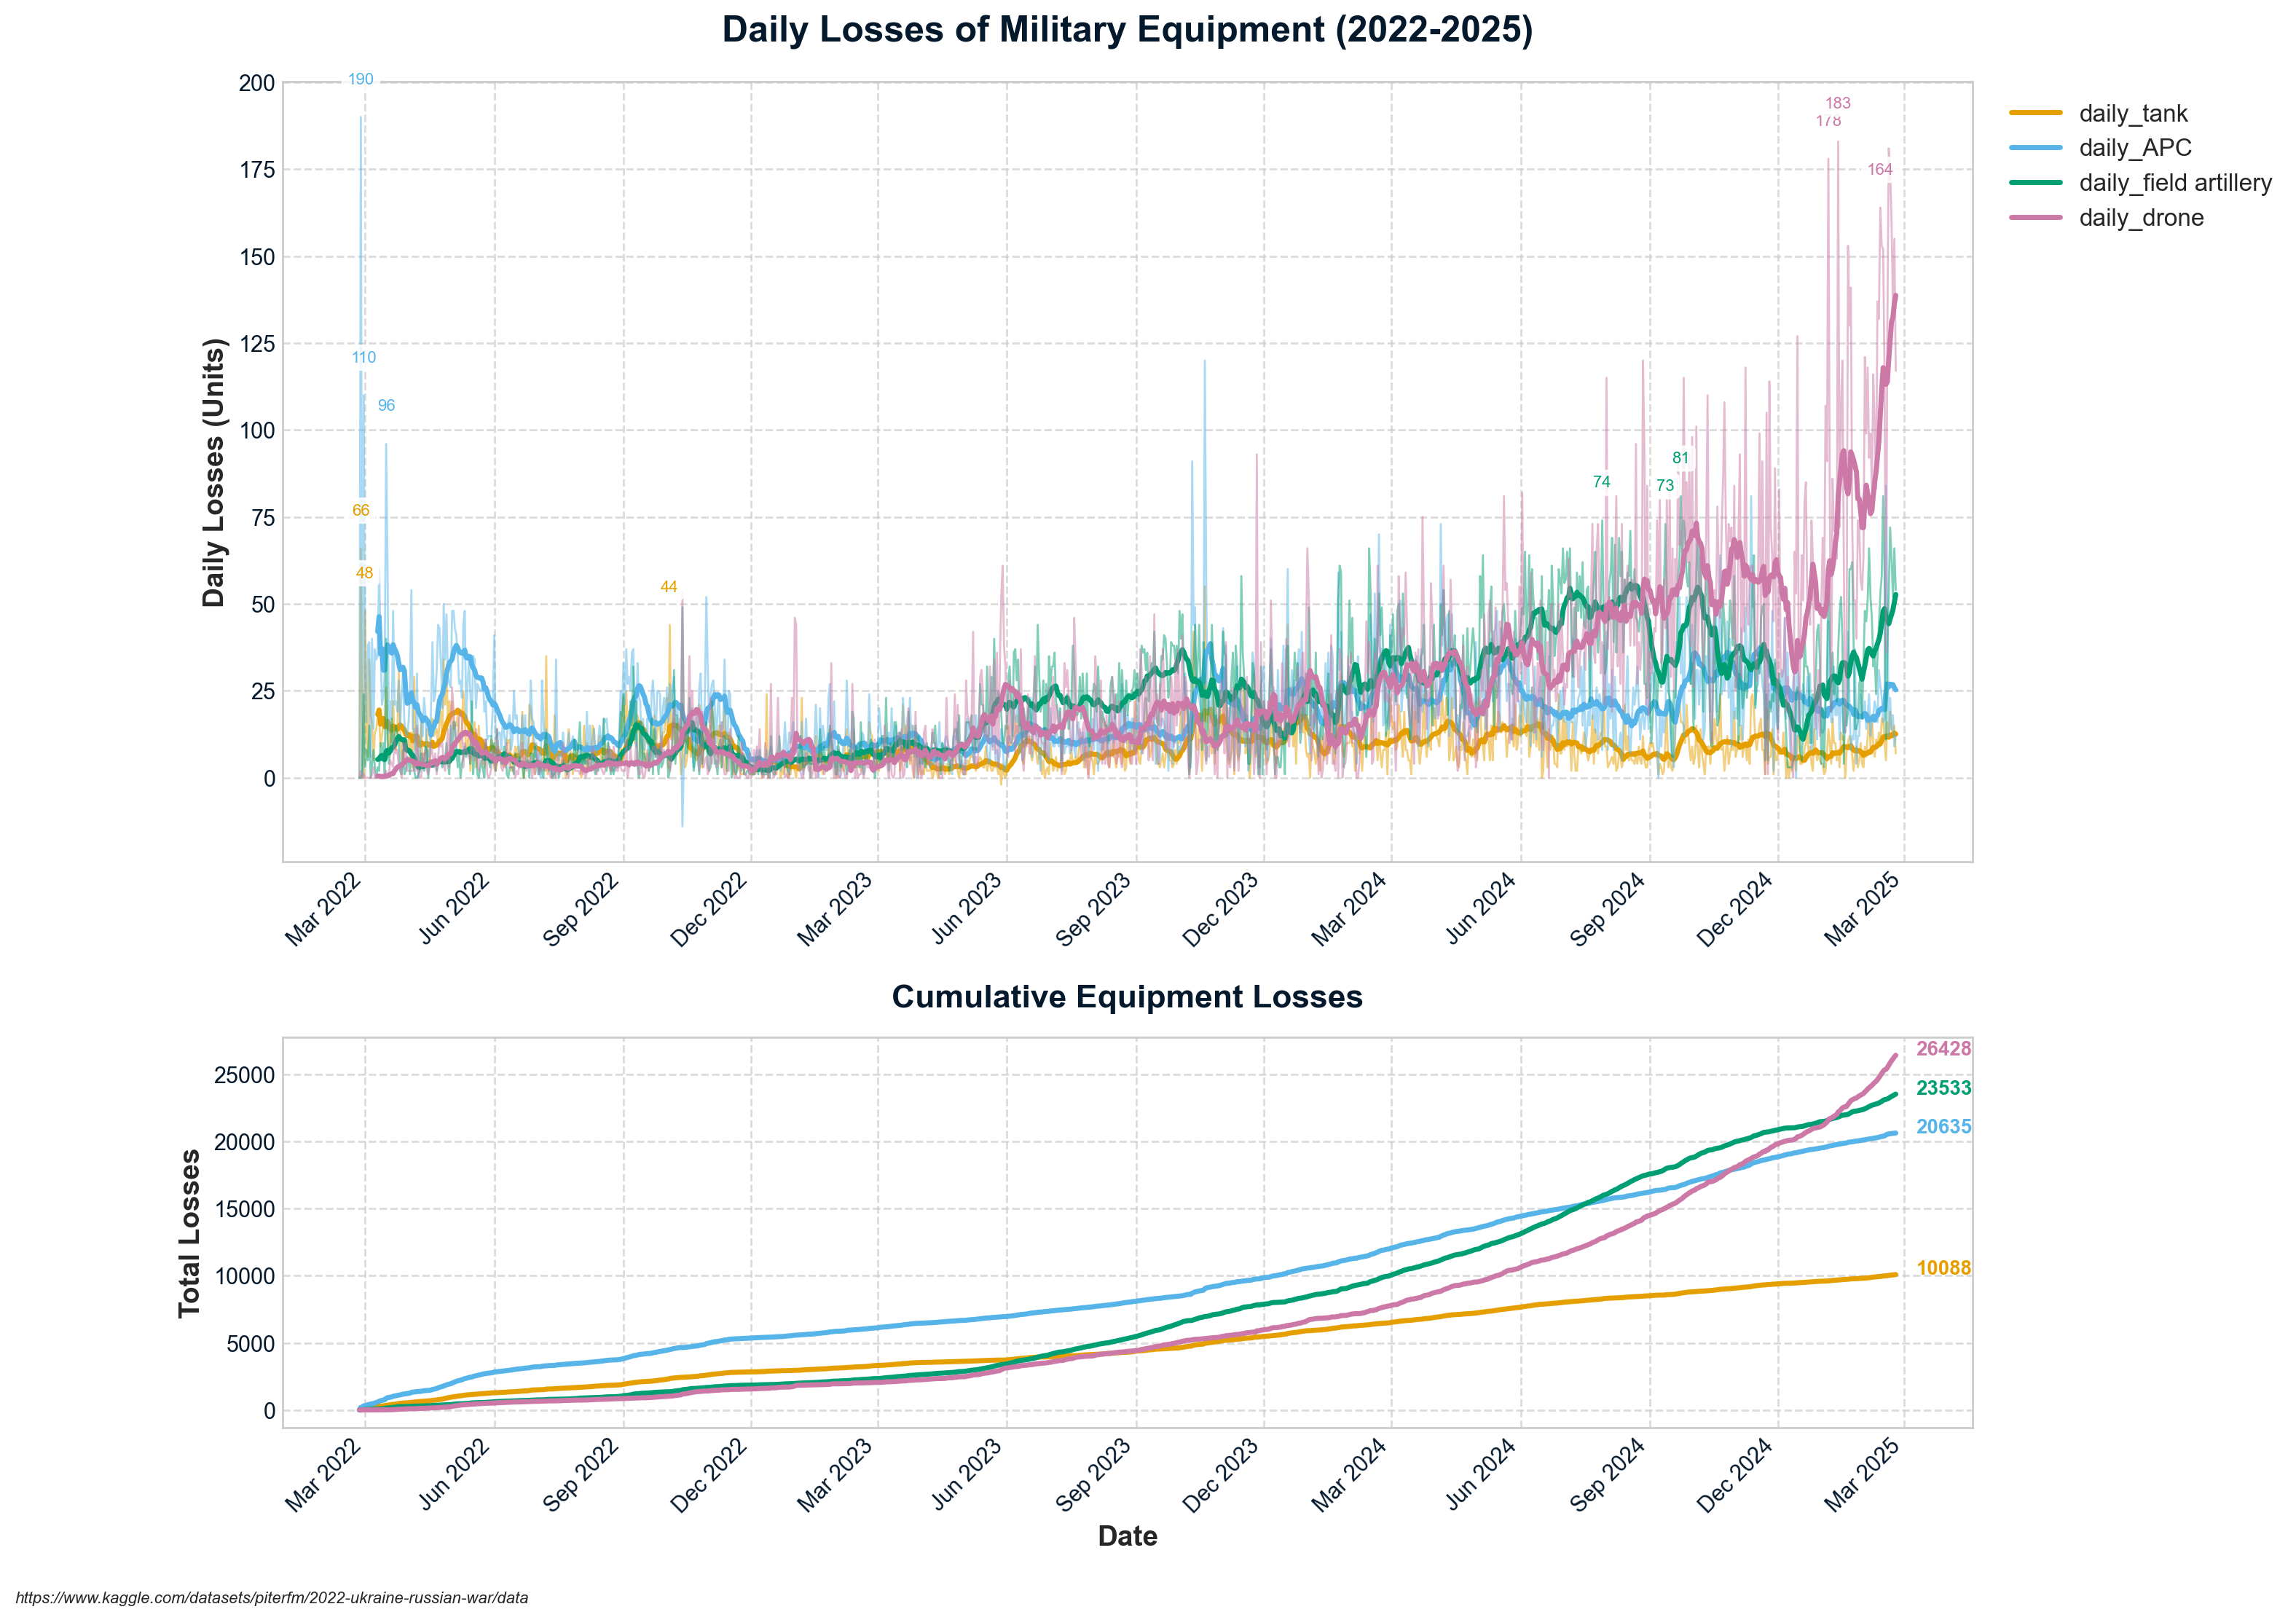

In [142]:
plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7']

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(2, 1, height_ratios=[2, 1], hspace=0.3)

ax1 = fig.add_subplot(gs[0])

# Plot each selected column with both raw data and smoothed trend
for i, col_name in enumerate(selected_columns):
    # Raw data with transparency
    ax1.plot(pandas_df.index, pandas_df[col_name], 
             alpha=0.5, color=colors[i], linewidth=1.0)
    
    # Add 14-day moving average for trend visibility
    pandas_df[f'{col_name}_ma'] = pandas_df[col_name].rolling(window=14).mean()
    ax1.plot(pandas_df.index, pandas_df[f'{col_name}_ma'], 
             label=col_name, color=colors[i], linewidth=2.5)

# Identify and annotate significant events (top 3 peaks for each category)
for i, col_name in enumerate(selected_columns):
    # Find top 3 peaks
    threshold = pandas_df[col_name].quantile(0.995)
    peaks = pandas_df[pandas_df[col_name] > threshold].index
    
    # Limit to at most 3 annotations per category to avoid cluttering
    for peak_date in peaks[:3]:
        value = pandas_df.loc[peak_date, col_name]
        ax1.annotate(f"{int(value)}",
                     xy=(peak_date, value),
                     xytext=(0, 15),
                     textcoords="offset points",
                     ha='center', va='bottom',
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
                     fontsize=8, color=colors[i])

# Format main plot
ax1.set_title("Daily Losses of Military Equipment (2022-2025)", fontsize=18, fontweight="bold", pad=20)
ax1.set_ylabel("Daily Losses (Units)", fontsize=14, fontweight="bold")
ax1.grid(True, linestyle='--', alpha=0.7)

# Format x-axis dates
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# Create legend outside the plot
ax1.legend(loc='upper left', bbox_to_anchor=(1.01, 1), 
          fancybox=True, shadow=True, fontsize=12)

# Subplot - Cumulative losses
ax2 = fig.add_subplot(gs[1], sharex=ax1)
for i, col_name in enumerate(selected_columns):
    # Calculate cumulative sum
    pandas_df[f'{col_name}_cum'] = pandas_df[col_name].cumsum()
    ax2.plot(pandas_df.index, pandas_df[f'{col_name}_cum'], 
             label=f"Total {col_name}", color=colors[i], linewidth=2.5)

# Format cumulative plot
ax2.set_title("Cumulative Equipment Losses", fontsize=16, fontweight="bold", pad=15)
ax2.set_ylabel("Total Losses", fontsize=14, fontweight="bold")
ax2.set_xlabel("Date", fontsize=14, fontweight="bold")
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

# Add totals at the end of each line
for i, col_name in enumerate(selected_columns):
    final_value = pandas_df[f'{col_name}_cum'].iloc[-1]
    ax2.annotate(f"{int(final_value)}",
                 xy=(pandas_df.index[-1], final_value),
                 xytext=(10, 0),
                 textcoords="offset points",
                 fontsize=10, fontweight='bold', color=colors[i])

# Improve layout and margins
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Make room for legend

# Add source attribution if needed
fig.text(0.01, 0.01, "https://www.kaggle.com/datasets/piterfm/2022-ukraine-russian-war/data", 
         fontsize=8, style='italic')

plt.show()

In [143]:
spark.stop()